In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

sns.set_style("whitegrid")

In [16]:
df = pd.read_csv("mall_customers.csv")
df.head(10)

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40
5,6,Female,22,17,76
6,7,Female,35,18,6
7,8,Female,23,18,94
8,9,Male,64,19,3
9,10,Female,30,19,72


In [17]:
df.shape
df.info()
df.describe()


<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   CustomerID              200 non-null    int64
 1   Gender                  200 non-null    str  
 2   Age                     200 non-null    int64
 3   Annual Income (k$)      200 non-null    int64
 4   Spending Score (1-100)  200 non-null    int64
dtypes: int64(4), str(1)
memory usage: 7.9 KB


,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


In [18]:

df.isnull().sum()



CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

In [19]:

df.rename(columns={
    'Annual Income (k$)' : 'Annual_Income',
    'Spending Score (1-100)' : 'Spending_Score'
}, inplace=True)

df.head()

,CustomerID,Gender,Age,Annual_Income,Spending_Score
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


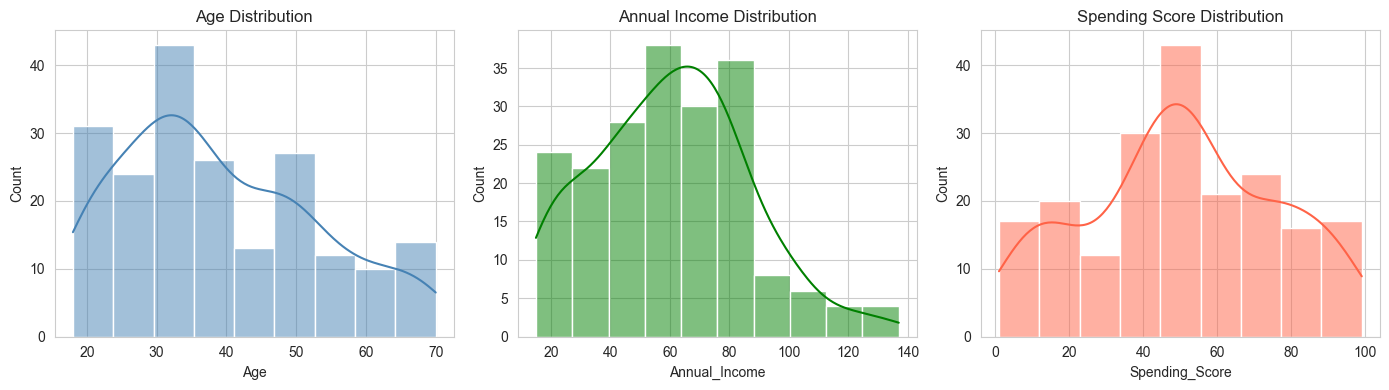

In [20]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

sns.histplot(df['Age'], kde=True, ax=axes[0], color='steelblue')
axes[0].set_title("Age Distribution")

sns.histplot(df['Annual_Income'], kde=True, ax=axes[1], color='green')
axes[1].set_title("Annual Income Distribution")

sns.histplot(df['Spending_Score'], kde=True, ax=axes[2], color='tomato')
axes[2].set_title("Spending Score Distribution")

plt.tight_layout()
plt.savefig("distributions.png", dpi=150)
plt.show()

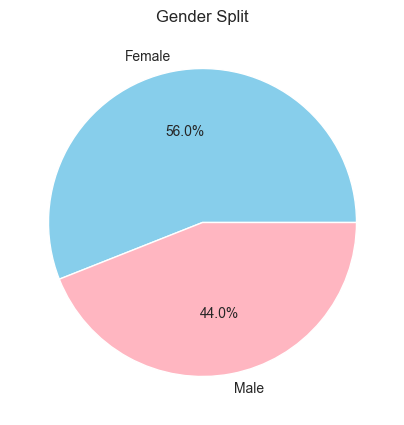

In [21]:
df['Gender'].value_counts().plot(kind='pie', autopct='%1.1f%%', figsize=(5,5), colors=['skyblue','lightpink'])
plt.title("Gender Split")
plt.ylabel("")
plt.savefig("gender_split.png", dpi=150)
plt.show()

In [22]:
# using Annual Income and Spending Score — classic combo for segmentation
X = df[['Annual_Income', 'Spending_Score']]
X.head()

,Annual_Income,Spending_Score
0,15,39
1,15,81
2,16,6
3,16,77
4,17,40


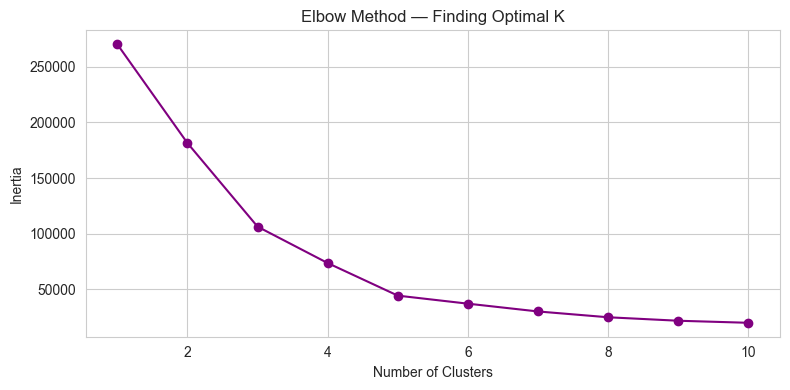

In [23]:
inertia = []

for k in range(1, 11):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X)
    inertia.append(km.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(range(1, 11), inertia, marker='o', color='purple')
plt.title("Elbow Method — Finding Optimal K")
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.tight_layout()
plt.savefig("elbow_curve.png", dpi=150)
plt.show()

# elbow is at k=5, so we'll go with that

In [24]:
km = KMeans(n_clusters=5, random_state=42, n_init=10)
df['Cluster'] = km.fit_predict(X)

df['Cluster'].value_counts()

Cluster
0    81
1    39
3    35
4    23
2    22
Name: count, dtype: int64

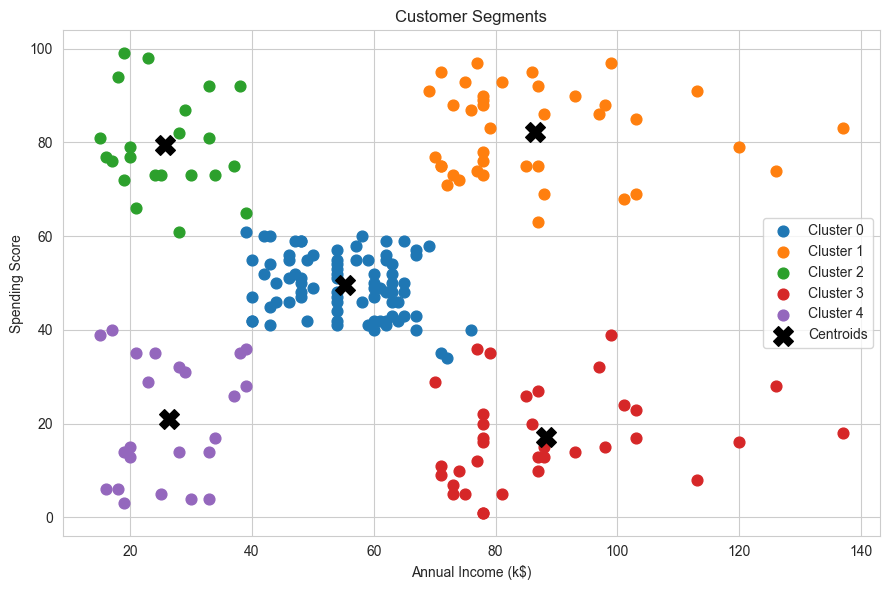

In [25]:
colors = ['red', 'blue', 'green', 'orange', 'purple']

plt.figure(figsize=(9, 6))
for i in range(5):
    cluster_data = df[df['Cluster'] == i]
    plt.scatter(cluster_data['Annual_Income'], cluster_data['Spending_Score'],
                label=f'Cluster {i}', s=60)

# plot centroids
centers = km.cluster_centers_
plt.scatter(centers[:, 0], centers[:, 1], c='black', marker='X', s=200, label='Centroids')

plt.title("Customer Segments")
plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score")
plt.legend()
plt.tight_layout()
plt.savefig("customer_clusters.png", dpi=150)
plt.show()

In [26]:
cluster_summary = df.groupby('Cluster')[['Age', 'Annual_Income', 'Spending_Score']].mean().round(1)
print(cluster_summary)

          Age  Annual_Income  Spending_Score
Cluster                                     
0        42.7           55.3            49.5
1        32.7           86.5            82.1
2        25.3           25.7            79.4
3        41.1           88.2            17.1
4        45.2           26.3            20.9


In [27]:
# based on the cluster summary above
cluster_labels = {
    0: 'Average Customers',
    1: 'High Income Low Spenders',
    2: 'Low Income Low Spenders',
    3: 'Low Income High Spenders',
    4: 'High Income High Spenders'
}

# note: your cluster numbers might be different — check Cell 12 output and relabel accordingly
df['Segment'] = df['Cluster'].map(cluster_labels)
df[['Annual_Income', 'Spending_Score', 'Cluster', 'Segment']].head(10)

,Annual_Income,Spending_Score,Cluster,Segment
0,15,39,4,High Income High Spenders
1,15,81,2,Low Income Low Spenders
2,16,6,4,High Income High Spenders
3,16,77,2,Low Income Low Spenders
4,17,40,4,High Income High Spenders
5,17,76,2,Low Income Low Spenders
6,18,6,4,High Income High Spenders
7,18,94,2,Low Income Low Spenders
8,19,3,4,High Income High Spenders
9,19,72,2,Low Income Low Spenders


C:\Users\utsav\AppData\Local\Temp\ipykernel_22016\3460747507.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Segment', palette='Set2', order=df['Segment'].value_counts().index)


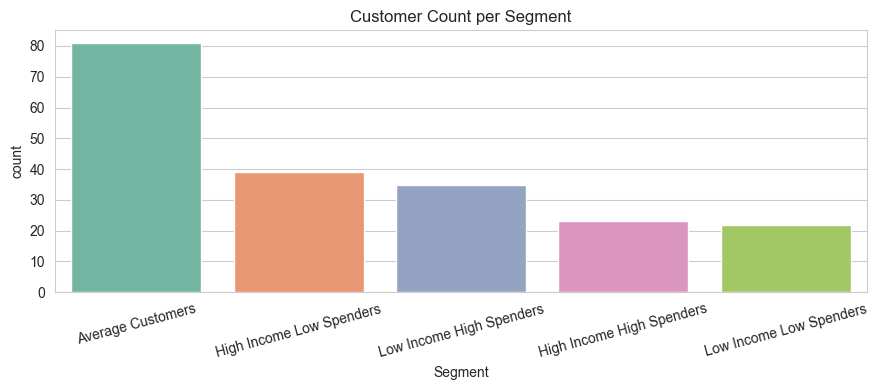

In [28]:
plt.figure(figsize=(9, 4))
sns.countplot(data=df, x='Segment', palette='Set2', order=df['Segment'].value_counts().index)
plt.title("Customer Count per Segment")
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig("segment_distribution.png", dpi=150)
plt.show()

In [29]:
df.to_csv("mall_customers_segmented.csv", index=False)
print("saved.")

saved.
